In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

I0000 00:00:1783878965.961431   59113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783878965.961924   59113 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783878965.996800   59113 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783878966.623509   59113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

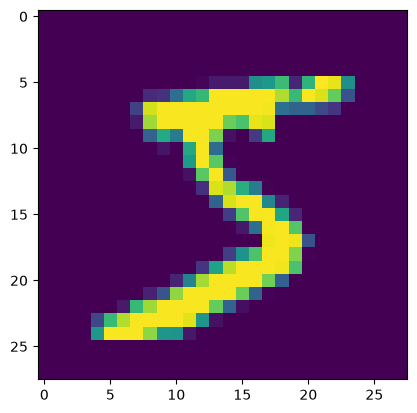

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

plt.imshow(x_train[0])

In [3]:
print(y_train[0])

5


In [4]:

x_train = x_train/255
x_test = x_test/255

print(x_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [5]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation="softmax")
    ]
)

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


E0000 00:00:1783878967.420917   59113 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1783878967.421162   59175 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1783878967.440208   59113 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
model.fit(x_train, y_train, epochs=100)

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 745us/step - accuracy: 0.9253 - loss: 0.2593
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 738us/step - accuracy: 0.9665 - loss: 0.1136
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step - accuracy: 0.9761 - loss: 0.0789
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 747us/step - accuracy: 0.9826 - loss: 0.0576
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step - accuracy: 0.9862 - loss: 0.0450
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step - accuracy: 0.9890 - loss: 0.0351
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 757us/step - accuracy: 0.9909 - loss: 0.0282
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 773us/step - accuracy: 0.9930 - loss: 0.0229
Epoch 9/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 756us/step - accuracy: 0.9945 - loss: 0.0179
Epoch 10/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - accuracy: 0.9952 - loss: 0.0151
Epoch 11/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - accuracy: 0.9959 - loss: 0.01

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


Text(0.5, 0, 'predicted value: 1')

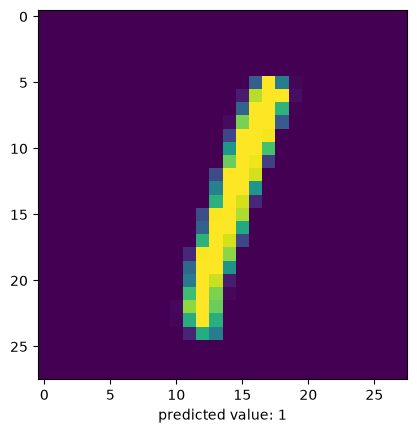

In [18]:
i = 5

image = x_test[i]
batched_image = np.expand_dims(image, axis=0)
y_pred = model.predict(batched_image)
plt.imshow(x_test[i])
plt.xlabel(f"predicted value: {np.argmax(y_pred)}")

In [19]:
y_pred_total = model.predict(x_test)

loss, accuracy = model.evaluate(x_test, y_test)

loss, accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step - accuracy: 0.9823 - loss: 0.1807


(0.18065927922725677, 0.9822999835014343)